In [322]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [323]:
df = pd.read_csv('financial_regression.csv')

In [324]:
df['date'] = pd.to_datetime(df['date'])


In [325]:
df

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.1400,114.4200,114.93,115646960.0,0.7200,46.26,46.520,46.2200,...,45.0200,43.8600,44.84,364528.0,1.1600,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.8400,113.2000,113.64,212252769.0,1.6400,46.46,46.550,45.6500,...,45.7600,44.4000,45.76,442210.0,1.3600,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.1300,113.5900,115.06,138671890.0,1.5400,45.96,46.640,45.9500,...,47.0800,45.7000,46.94,629150.0,1.3800,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.4500,112.9800,113.89,216330645.0,1.4700,46.27,46.604,45.4300,...,47.3100,45.1700,47.05,643198.0,2.1400,109.97,110.05,108.46,108.94,17534231.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,96.0259,94.5400,95.68,52414.0,1.4859,247.75,249.06,247.62,248.63,5176170.0
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,99.6600,97.2700,99.46,205027.0,2.3900,250.00,251.37,249.90,251.27,7833614.0
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,98.3500,95.8900,97.35,227394.0,2.4600,252.74,253.14,250.73,251.22,9258590.0
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,99.5899,97.9600,99.41,136431.0,1.6299,253.06,253.94,252.52,253.93,5756321.0


In [326]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                3904 non-null   datetime64[ns]
 1   sp500 open          3719 non-null   float64       
 2   sp500 high          3719 non-null   float64       
 3   sp500 low           3719 non-null   float64       
 4   sp500 close         3719 non-null   float64       
 5   sp500 volume        3719 non-null   float64       
 6   sp500 high-low      3719 non-null   float64       
 7   nasdaq open         3719 non-null   float64       
 8   nasdaq high         3719 non-null   float64       
 9   nasdaq low          3719 non-null   float64       
 10  nasdaq close        3719 non-null   float64       
 11  nasdaq volume       3719 non-null   float64       
 12  nasdaq high-low     3719 non-null   float64       
 13  us_rates_%          176 non-null    float64     

In [327]:
df.isna().sum()

date                     0
sp500 open             185
sp500 high             185
sp500 low              185
sp500 close            185
sp500 volume           185
sp500 high-low         185
nasdaq open            185
nasdaq high            185
nasdaq low             185
nasdaq close           185
nasdaq volume          185
nasdaq high-low        185
us_rates_%            3728
CPI                   3728
usd_chf                210
eur_usd                210
GDP                   3847
silver open            185
silver high            185
silver low             185
silver close           185
silver volume          185
silver high-low        185
oil open               185
oil high               185
oil low                185
oil close              185
oil volume             185
oil high-low           185
platinum open          185
platinum high          185
platinum low           185
platinum close         185
platinum volume        185
platinum high-low      185
palladium open         185
p

In [328]:
df = df.sort_values('date', ascending=True)


In [329]:
df = df.sort_values('date')


In [331]:
df

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high-low,gold open,gold high,gold low,gold close,gold volume,gold_lag_1,gold_lag_2,gold_lag_3,gold_rolling_7
6,2010-01-22,111.20,111.7400,109.0900,109.21,345627282.0,2.6500,45.34,45.480,44.0400,...,1.7860,106.93,107.68,106.01,107.170,24209966.0,107.370,108.94,111.52,109.821429
7,2010-01-25,110.21,110.4100,109.4100,109.77,186751367.0,1.0000,44.39,44.600,44.1200,...,0.9900,107.44,107.72,107.07,107.480,13170442.0,107.170,107.37,108.94,109.171429
8,2010-01-26,109.34,110.4700,109.0400,109.31,210788669.0,1.4300,44.28,44.890,44.0500,...,0.7200,106.87,107.99,106.75,107.560,12274165.0,107.480,107.17,107.37,108.700000
9,2010-01-27,109.17,110.0800,108.3300,109.83,271482263.0,1.7500,44.29,44.850,44.0100,...,1.5100,107.53,108.80,106.16,106.528,18991219.0,107.560,107.48,107.17,108.081143
10,2010-01-28,110.19,110.2500,107.9100,108.57,315523641.0,2.3400,44.40,44.430,43.3200,...,1.7800,107.18,107.23,105.18,106.480,16792253.0,106.528,107.56,107.48,107.361143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,1.4859,247.75,249.06,247.62,248.630,5176170.0,247.150,245.92,245.07,245.158571
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,2.3900,250.00,251.37,249.90,251.270,7833614.0,248.630,247.15,245.92,246.618571
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,2.4600,252.74,253.14,250.73,251.220,9258590.0,251.270,248.63,247.15,247.818571
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,1.6299,253.06,253.94,252.52,253.930,5756321.0,251.220,251.27,248.63,249.027143


In [332]:
df = df.dropna(subset=df.columns.drop('date'), how='all')

In [333]:
df = df.reset_index(drop=True)


In [334]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df = df.drop(columns=['date'])

In [335]:
df = df.fillna(method='ffill').fillna(method='bfill')


C:\Users\USER\AppData\Local\Temp\ipykernel_10680\1140751661.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


In [336]:
y = df['gold close']
X = df.drop(columns=['gold close'])

In [337]:
train_size = int(len(df) * 0.8)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


In [338]:
from xgboost import XGBRegressor
model = XGBRegressor()

In [339]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [340]:
y_pred = model.predict(X_test)

In [341]:
y_pred

array([173.66928, 174.80171, 174.54184, 174.77353, 173.67017, 174.76164,
       174.04697, 173.59955, 169.41643, 167.88765, 167.65602, 167.61339,
       167.68317, 167.22446, 168.0363 , 167.58768, 166.32715, 166.17255,
       166.9592 , 166.83063, 166.77484, 166.2965 , 166.70934, 167.08823,
       166.20049, 165.94313, 167.92647, 169.09975, 167.7958 , 167.76097,
       167.7975 , 168.95993, 168.95993, 169.49112, 169.17847, 167.70073,
       169.0216 , 171.06514, 171.16461, 169.29263, 169.90825, 170.07263,
       167.8124 , 167.80702, 167.60287, 169.43849, 171.13757, 169.8451 ,
       169.73174, 169.75644, 169.68135, 170.83348, 171.17249, 171.33275,
       171.23334, 172.33707, 169.3353 , 168.3744 , 167.56284, 167.19406,
       167.8958 , 168.8006 , 167.67459, 168.81938, 169.9303 , 170.72696,
       170.89624, 171.12764, 172.75441, 174.61769, 172.2711 , 174.63536,
       175.74461, 175.81616, 175.81546, 177.20961, 177.15758, 176.83269,
       175.73409, 177.25925, 179.32568, 179.61676, 

In [342]:
from sklearn.metrics import mean_absolute_error, r2_score


In [343]:
mae = mean_absolute_error(y_test, y_pred)
mae

8.676190566625353

In [344]:
r2 = r2_score(y_test, y_pred)
r2

0.33870678185996517

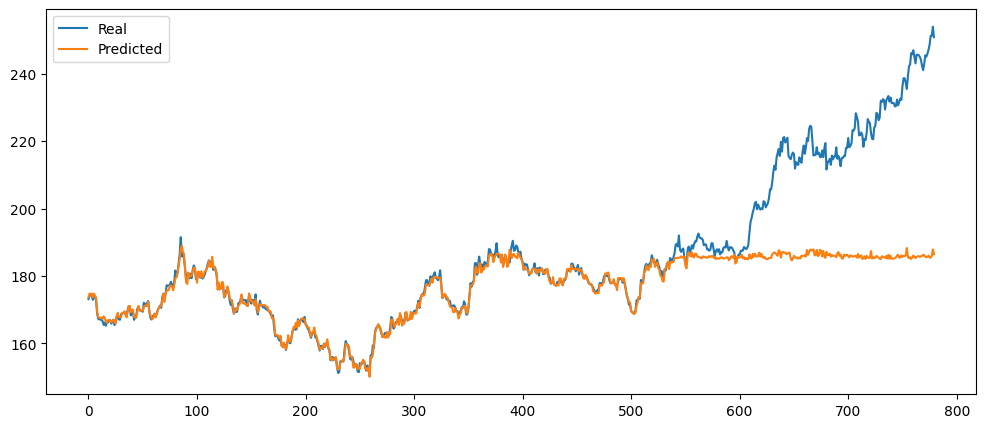

In [345]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()
